<a href="https://colab.research.google.com/github/PedroNishimura/SpaceShuttleLab/blob/main/coffeeModelTCC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### Importações das bibliotecas ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
### Leitura da base ###
df = pd.read_excel('/content/2024.12.PLANILHAO-EXPORTACOES.xlsx', sheet_name='PREÇO MÉDIO (US$ - SACA)', skiprows=1)

In [ ]:
### Cabeçalho da base ###
df.head()

,Mês/Ano,Conillon,Arábica,Total Café Verde,Torrado,Solúvel,Total Industrializado,TOTAL GERAL
0,2024-12-31,251.940975,315.913774,305.495214,469.633565,271.608610,273.349612,301.988707
1,2024-11-30,253.734400,298.442575,290.433939,583.915456,256.248558,261.709774,288.199496
2,2024-10-31,250.918380,294.434288,286.057741,565.530895,249.535678,253.933469,283.812780
3,2024-09-30,238.033250,278.740728,269.782518,496.306807,244.946178,247.862019,268.032070
4,2024-08-31,221.031449,270.186956,256.868796,467.968749,247.740792,250.348625,256.314707


In [ ]:
### Tratamento geral do DataFrame ###
df = df[['Mês/Ano', 'Conillon', 'Arábica']]

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df['conillon'] = df['conillon'].astype(int)
df['arábica'] = df['arábica'].astype(int)

df.dropna(how='all', inplace=True)
df.dropna(axis=1, how='all', inplace=True)

linhasZeradas = df[(df['conillon'] == 0) & (df['arábica'] == 0)]
df = df.drop(linhasZeradas.index[:3])

df['trimestre'] = df['mês/ano'].dt.quarter

df['mês/ano'] = pd.to_datetime(df['mês/ano'], format='%m/%Y')
df = df.sort_values('mês/ano').reset_index(drop=True)

df['tempo'] = np.arange(len(df))

In [ ]:
### Informações sobre o DataFrame ###
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   mês/ano    417 non-null    datetime64[ns]
 1   conillon   417 non-null    int64         
 2   arábica    417 non-null    int64         
 3   trimestre  417 non-null    int32         
 4   tempo      417 non-null    int64         
dtypes: datetime64[ns](1), int32(1), int64(3)
memory usage: 14.8 KB


In [ ]:
### Descrição do DataFrame ###
df.describe()

,mês/ano,conillon,arábica,trimestre,tempo
count,417,417.000000,417.000000,417.000000,417.000000
mean,2007-08-07 09:53:57.410072064,98.764988,144.146283,2.510791,208.000000
min,1990-04-01 00:00:00,24.000000,46.000000,1.000000,0.000000
25%,1998-12-01 00:00:00,63.000000,97.000000,2.000000,104.000000
50%,2007-08-01 00:00:00,99.000000,139.000000,3.000000,208.000000
75%,2016-04-01 00:00:00,130.000000,179.000000,4.000000,312.000000
max,2024-12-31 00:00:00,253.000000,315.000000,4.000000,416.000000
std,NaN,43.240021,60.641326,1.116099,120.521782


In [ ]:
### Demonstração das colunas categóricas e numéricas ###
numCols = df.select_dtypes(include=[np.number]).columns.tolist()
catCols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nColunas Numéricas:", numCols)
print("Colunas Categóricas:", catCols)


Colunas Numéricas: ['conillon', 'arábica', 'trimestre', 'tempo']
Colunas Categóricas: ['mês/ano']


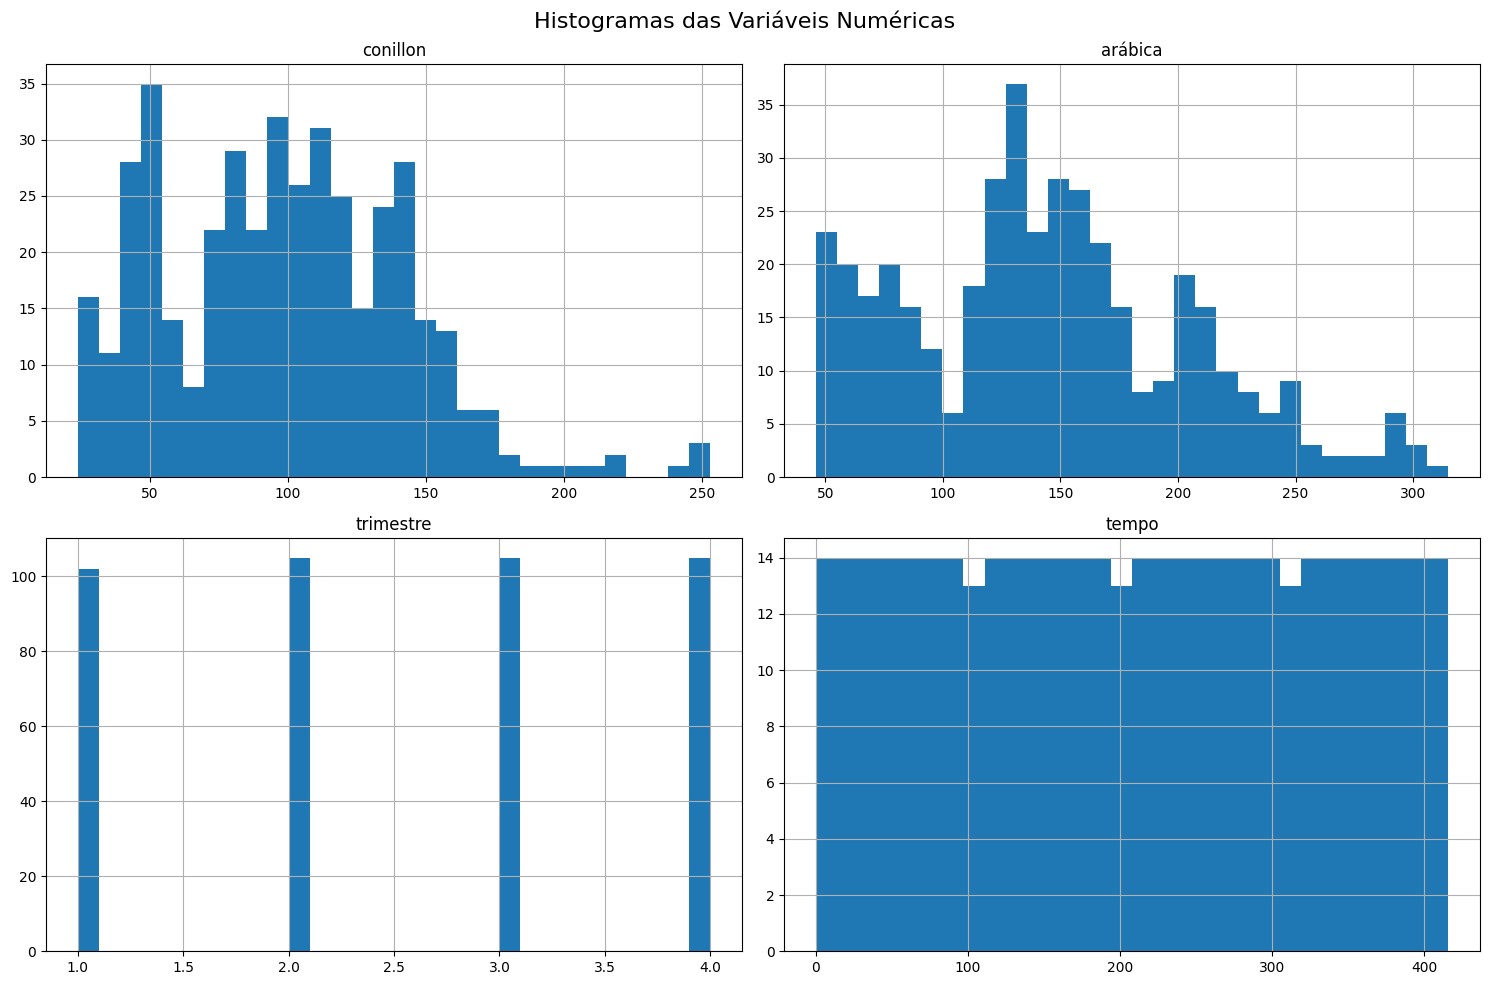

In [ ]:
### Histograma das variáveis ###
df[numCols].hist(bins=30, figsize=(15, 10))

plt.suptitle("Histogramas das Variáveis Numéricas", fontsize=16)
plt.tight_layout()
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe8738fb710>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe8738e8ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe8738fadd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fe8738e9d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fe8738ea610>],
 'means': []}

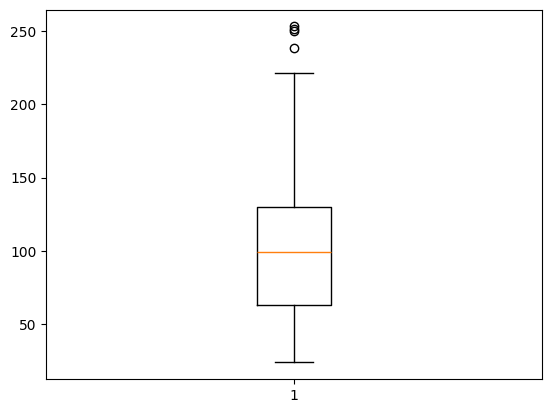

In [ ]:
### Boxplot de conillon ###
plt.boxplot(df['conillon'].values)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe873945110>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe8739464d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe873944690>],
 'medians': [<matplotlib.lines.Line2D at 0x7fe8739477d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fe873948150>],
 'means': []}

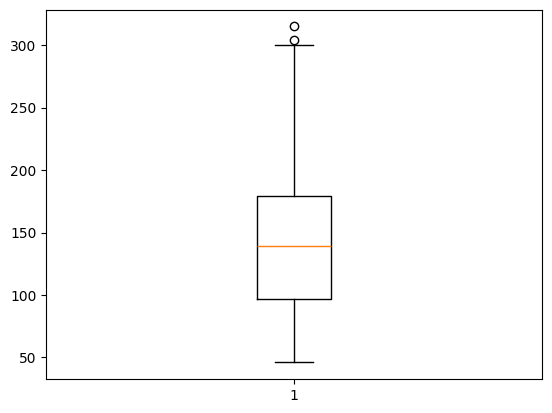

In [ ]:
### Boxplot de arábica ###
plt.boxplot(df['arábica'].values)

In [ ]:
### Quartil e Outliers das variáveis ###
print("\n### Quartil e Outliers das variáveis ###")
for col in numCols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\nColuna: {col}")
    print(f"1º Quartil: {Q1:.2f}, 3º Quartil: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Limite Inferior: {limite_inferior:.2f}, Limite Superior: {limite_superior:.2f}")

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Número de outliers em {col}: {outliers.shape[0]}")


### Quartil e Outliers das variáveis ###

Coluna: conillon
1º Quartil: 63.00, 3º Quartil: 130.00, IQR: 67.00
Limite Inferior: -37.50, Limite Superior: 230.50
Número de outliers em conillon: 4

Coluna: arábica
1º Quartil: 97.00, 3º Quartil: 179.00, IQR: 82.00
Limite Inferior: -26.00, Limite Superior: 302.00
Número de outliers em arábica: 2

Coluna: trimestre
1º Quartil: 2.00, 3º Quartil: 4.00, IQR: 2.00
Limite Inferior: -1.00, Limite Superior: 7.00
Número de outliers em trimestre: 0

Coluna: tempo
1º Quartil: 104.00, 3º Quartil: 312.00, IQR: 208.00
Limite Inferior: -208.00, Limite Superior: 624.00
Número de outliers em tempo: 0


In [ ]:
### Função para calcular as métricas ###
def calcularMetricas(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return r2, rmse, mae

In [ ]:
### Variáveis de treino e teste ###
X = df[['tempo']]
yConillon = df['conillon']
yArabica = df['arábica']

XTrain, XTest, yConillonTrain, yConillonTest = train_test_split(X, yConillon, test_size=0.2, random_state=42)
_, _, yArabicaTrain, yArabicaTest = train_test_split(X, yArabica, test_size=0.2, random_state=42)

In [ ]:
### Treino e Teste LinearRegression ###
lrConillon = LinearRegression().fit(XTrain, yConillonTrain)
lrArabica = LinearRegression().fit(XTrain, yArabicaTrain)

lrPredictConillon = lrConillon.predict(XTest)
lrPredictArabica = lrArabica.predict(XTest)

r2LrConillon, rmseLrConillon, maeLrConillon = calcularMetricas(yConillonTest, lrPredictConillon)
r2LrArabica, rmseLrArabica, maeLrArabica = calcularMetricas(yArabicaTest, lrPredictArabica)

In [ ]:
### Treino e Teste Prophet ###
dfConillon = df[['mês/ano', 'conillon']].rename(columns={'mês/ano': 'ds', 'conillon': 'y'})
dfArabica = df[['mês/ano', 'arábica']].rename(columns={'mês/ano': 'ds', 'arábica': 'y'})

modelConillon = Prophet()
modelConillon.fit(dfConillon)

modelArabica = Prophet()
modelArabica.fit(dfArabica)

future = modelConillon.make_future_dataframe(periods=12, freq='ME')
forecastConillon = modelConillon.predict(future)

future = modelArabica.make_future_dataframe(periods=12, freq='ME')
forecastArabica = modelArabica.predict(future)

conillonPredictTest = modelConillon.predict(dfConillon[['ds']])['yhat']
arabicaPredictTest = modelArabica.predict(dfArabica[['ds']])['yhat']

r2ProphetConillon, rmseProphetConillon, maeProphetConillon = calcularMetricas(dfConillon['y'], conillonPredictTest)
r2ProphetArabica, rmseProphetArabica, maeProphetArabica = calcularMetricas(dfArabica['y'], arabicaPredictTest)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7qvh3v5g/3lcqw3lb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7qvh3v5g/dmn132wh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=20784', 'data', 'file=/tmp/tmp7qvh3v5g/3lcqw3lb.json', 'init=/tmp/tmp7qvh3v5g/dmn132wh.json', 'output', 'file=/tmp/tmp7qvh3v5g/prophet_model8ca1rnqn/prophet_model-20250802000029.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:00:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:00:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonalit

In [ ]:
### Tabela com as métricas de desempenho ###
tabela_resultados = pd.DataFrame({
    'Modelo': ['Linear Regression - Conillon', 'Prophet - Conillon',
               'Linear Regression - Arabica', 'Prophet - Arabica'],
    'R² (teste)': [r2LrConillon, r2ProphetConillon, r2LrArabica, r2ProphetArabica],
    'RMSE (teste)': [rmseLrConillon, rmseProphetConillon, rmseLrArabica, rmseProphetArabica],
    'MAE (teste)': [maeLrConillon, maeProphetConillon, maeLrArabica, maeProphetArabica]
})

print("\n### MÉTRICAS DE DESEMPENHO ###")
print(tabela_resultados)


### MÉTRICAS DE DESEMPENHO ###
                         Modelo  R² (teste)  RMSE (teste)  MAE (teste)
0  Linear Regression - Conillon    0.315541     41.147127    31.513735
1            Prophet - Conillon    0.366687     34.369553    27.368282
2   Linear Regression - Arabica    0.416415     46.951632    38.105933
3             Prophet - Arabica    0.348728     48.879700    37.938985


In [ ]:
### Previsão para 2025 de LinearRegression e Prophet ###
forecastConillon12 = forecastConillon[['ds', 'yhat']].tail(12).copy()
forecastConillon12['ds'] = forecastConillon12['ds'].dt.strftime('%m/%Y')

forecastArabica12 = forecastArabica[['ds', 'yhat']].tail(12).copy()
forecastArabica12['ds'] = forecastArabica12['ds'].dt.strftime('%m/%Y')

mesesFuturos = np.arange(df['tempo'].max() + 1, df['tempo'].max() + 13).reshape(-1, 1)
mesesPrevistos = pd.date_range(df['mês/ano'].max() + pd.DateOffset(months=1), periods=12, freq='ME').strftime('%m/%Y')

lrConillonPredict = lrConillon.predict(mesesFuturos)
lrArabicaPredict = lrArabica.predict(mesesFuturos)

df_previsao = pd.DataFrame({
    'mês/ano': mesesPrevistos,
    'conillon_LR': np.round(lrConillonPredict, 2),
    'conillon_prophet': np.round(forecastConillon12['yhat'].values, 2),
    'arabica_LR': np.round(lrArabicaPredict, 2),
    'arabica_prophet': np.round(forecastArabica12['yhat'].values, 2)
})

print("\n### PREVISÃO PARA 2025 ###")
print(df_previsao)


### PREVISÃO PARA 2025 ###
    mês/ano  conillon_LR  conillon_prophet  arabica_LR  arabica_prophet
0   01/2025       137.35            149.76      203.89           208.49
1   02/2025       137.54            151.16      204.18           210.28
2   03/2025       137.73            150.15      204.47           211.73
3   04/2025       137.92            148.68      204.76           213.08
4   05/2025       138.11            147.22      205.05           212.64
5   06/2025       138.30            146.34      205.34           211.79
6   07/2025       138.49            147.09      205.63           211.38
7   08/2025       138.68            147.32      205.91           211.63
8   09/2025       138.87            150.87      206.20           212.41
9   10/2025       139.07            150.37      206.49           213.14
10  11/2025       139.26            153.91      206.78           215.29
11  12/2025       139.45            152.55      207.07           217.06


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
